<a href="https://colab.research.google.com/github/Adrian117-b1-27/sistemas-inteligentes/blob/main/07_EnfoqueEstadistico_NaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje Supervisado: Clasificación

## Clasificación

- Es un tipo de aprendizaje supervisado: Se conoce la clase verdadera de cada uno de los ejemplos que se utilizan para construir el clasificador
- El problema de clasificación consiste en predecir una determinada clase (categoría) para un objeto.
- **La tarea de clasificación**: Dados un conjunto de ejemplos ya clasificados, construir un modelo o clasificador que permita clasificar nuevos casos
- El problema fundamental de la clasificación está directamente relacionado con la separabilidad de las clases.



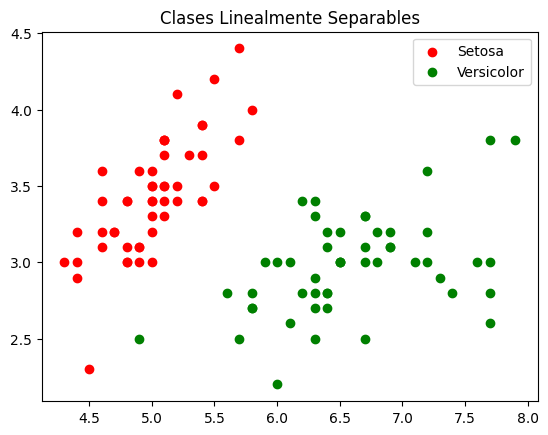

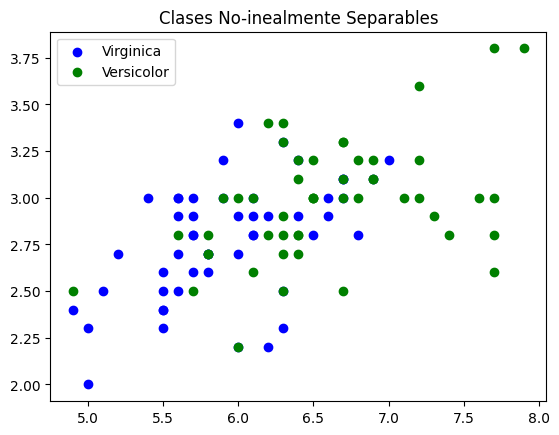

In [ ]:
# visualizamos cada clase de un color diferente

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
datosIris = load_iris()
plt.figure(1)
plt.title('Clases Linealmente Separables')
plt.scatter(datosIris['data'][0:50,0],datosIris['data'][0:50,1],color ='red', label = 'Setosa')
plt.scatter(datosIris['data'][100:150,0],datosIris['data'][100:150,1],color ='green', label = 'Versicolor')
plt.legend()

plt.figure(2)
plt.title('Clases No-inealmente Separables')
plt.scatter(datosIris['data'][50:100,0],datosIris['data'][50:100,1],color ='blue', label = 'Virginica')
plt.scatter(datosIris['data'][100:150,0],datosIris['data'][100:150,1],color ='green', label = 'Versicolor')
plt.legend()

## Algoritmos de Clasificación

Ente los algoritmos de clasificación más utlizados, destacan:
+ Vecino más cercano
+ Clasificador Bayesiano Ingenuo (Naive Bayes)
+ Regresión Logística
+ Perceptrón
+ Árboles de decisión
+ Support vector machines
....




# Clasificadores Bayesianos Ingenuos (Naive Bayes Classifiers)

Naive Bayes es un algoritmo de aprendizaje automático para problemas de clasificación. Esta basado en el teorema de probabilidad de Bayes. Se utiliza éxitosamente, entre otras aplicacionesente, para la clasificación de texto la cual implica conjuntos de datos de entrenamiento con una alta dimensionalidad. Algunos ejemplos son filtración de correos basura, análisis de sentimiento y clasificación de artículos de noticias.

No sólo es conocido por su simplicidad, sino también por su eficacia. Es rápido construir modelos y hacer predicciones con el algoritmo Naive Bayes. En general se recomienda a Naive Bayes  entre los primeros algoritmos a considerar para resolver problemas de clasificación de texto.

## ¿Qué es el algoritmo Naive Bayes?

Naive Bayes es un algoritmo que aprende la probabilidad de que un objeto con ciertos atributos pertenesca a un grupo o una clase en particular. En resumen, es un clasificador probabilístico. ¿Por qué se llama así?

El algoritmo Naive Bayes se llama "ingenuo" porque hace la suposición de que la ocurrencia de un atributo en particular es independiente de la ocurrencia de los otros atributos.

Por ejemplo, si tratamos de identificar una fruta basada en su color, forma y sabor, entonces una fruta de color naranja, esférica y ácida sería muy probablemente una naranja. Incluso si estos atributos dependen unos de otros o de la presencia de las otros atributos, todas estos atributos contribuyen individualmente a la probabilidad de que esta fruta es una naranja y es por eso que se conoce como "ingenuo".

En cuanto a la parte de "Bayes", se refiere al estadístico y filósofo, Thomas Bayes y el teorema que lleva su nombre, el teorema de Bayes, que es la base para el Algoritmo Naive Bayes.

## Las Matemáticas del Algoritmo Naive Bayes

La base del algoritmo Naive Bayes es el Teorema de Bayes o también conocido como la Regla de Bayes o la Ley de Bayes. Nos da un método para calcular la probabilidad condicional, es decir, la probabilidad de un evento basado en conocimientos previos disponibles sobre los eventos. Más formalmente, el teorema de Bayes se expresa como la siguiente ecuación:

$$P(A|B) = \frac{P(B|A)\times P(A)}{P(B)}$$

Entendamos la declaración primero y luego examinaremos la prueba de la declaración. Los componentes de la declaración anterior son:

- $P (A|B)$: Probabilidad (probabilidad condicional) de ocurrencia del evento A dado el evento B es verdadero
- $P (A)$ y $P (B)$: Probabilidades de la ocurrencia del evento A y B respectivamente
- $P (B | A)$: Probabilidad de la ocurrencia del evento B dado que el evento A es verdadero

La terminología del método bayesiano de probabilidad (más comúnmente utilizada) es la siguiente:

$$P(h|D) = \frac{P(D|h)\times P(h)}{P(D)}$$

- $h$ se le denomina la hipótesis y a $D$ se le denomina la observación.
- $P(h)$  Probabilidad de que la hipótesis `h` sea cierta o probabilidad a priori de la hipótesis `h`.
- $P(D)$  Probabilidad de que recibamos la observación `D` o probabilidad a priori de la observación `D`.
- $P(D|h)$  Probabilidad de observar el dato `D`, cuando se cumple la hipótesis `h` o probabilidad a posteriori de la observación `D`.
- $P(h|D)$  Probabilidad de que se cumpla la hipótesis `h`, dado que se ha obtenido el dato `D`, o probabilidad a posteriori de la hipótesis `h`.


Por lo que podemos reescribir el Teorema de Bayes como:

$$Probabilidad\ posterior\ hipótesis = \frac{(Verosimilitud)\times (Probabilidad\ previa\ hipótesis)}{Probabilidad\ previa\ observación}$$

En general estamos interesados en calcular el **decisor máximo a posteriori**:

$$h_{MAP}=argmax_h\ P(h|D) = argmax_h\ \frac{P(D|h)\times P(h)}{P(D)}$$

Dado que $P(D)$ es constante para todas las hipótesis, lo podemos eliminar

$$h_{MAP}=argmax_h\ P(h|D) = argmax_h\ {P(D|h)\times P(h)}$$

En el caso de que todas las hipótesis sea equiprobables a priori. Se puede calcular el **decisor de máxima verosimilitud**:

$$h_{ML}=argmax_h\ P(D|h)$$

**Tomemos un ejemplo para entender mejor el teorema de Bayes.**

Supongamos que usted tiene que sacar una sola carta de una baraja estándar de 52 cartas. Ahora la probabilidad de que la carta sea una Reina es $P(Reina) = \frac{4}{52} = \frac{1}{13}$. Si se le da evidencia de que la carta que ha escogido es una carta con una persona, la probabilidad posterior $P(Reina | Persona)$ se puede calcular usando el teorema de Bayes como sigue:

$$P(Reina|Persona) = \frac{P(Persona|Reina)\times P(Reina)}{P(Persona)}$$

Ahora $P (Persona | Reina) = 1$ porque dada que la carta es una reina, es definitivamente una carta de una persona. Ya hemos calculado $P(Reina)$. El único valor que queda para calcular es $P(Persona)$, que es igual a $\frac {3} {13}$ ya que hay tres cartas de personas para cada palo en una baraja. Por lo tanto,

$$P(Reina|Persona) = 1 \times \frac{1}{13}\times \frac{13}{3}=\frac{1}{3}$$

## Clasificación usando Naive Bayes

En un problema de clasificación de aprendizaje automático, hay varios atributos y clases, digamos, $C_1, C_2, \ldots, C_k$. El objetivo principal del algoritmo Naive Bayes es calcular la probabilidad condicional de que un objeto con un vector de atributos $x_1, x_2, \ldots, x_n$ pertenezca a una clase particular $C_i$,

$$P(C_i|x_1, x_2, \ldots, x_n) = \frac{P(x_1, x_2, \ldots, x_n|C_i)\times P(C_i)}{P(x_1, x_2, \ldots, x_n)}\ para\ 1 ≤ i ≤ k$$

Dada la suposición de que los atributos son independientes podemos decir que:

$$P(C_i|x_1, x_2, \ldots, x_n) = (\prod_{j=1}^{j=n}P(x_j|C_i))\times \frac{P(C_i)}{P(x_1, x_2, \ldots, x_n)}\ para\ 1 ≤ i ≤ k$$

La expresion $P(x_1, x_2, \ldots, x_n)$ es constante para todas las clases, podemos entonces decir que

$$P(C_i|x_1, x_2, \ldots, x_n) = (\prod_{j=1}^{j=n}P(x_j|C_i))\times P(C_i)\ para\ 1 ≤ i ≤ k$$

## ¿Cómo funciona el Algoritmo Naive Bayes?

Hasta ahora hemos aprendido cuál es el algoritmo Naive Bayes, cómo se relaciona el Teorema de Bayes con él y cuál es la expresión del Teorema de Bayes para este algoritmo. Tomemos un ejemplo simple la siguente tabla con ejemplos si debemos jugar al tenis bajo ciertas circunstancias. Éstas podrían ser el clima, la temperatura, la humedad y la fuerza del viento.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
datos = pd.read_csv('/content/drive/MyDrive/Sistemas Inteligentes/VersionColab/Datos/temperatura.csv')
datos

,Clima,Temperatura,Humedad,Viento,Jugar_Tenis
0,Soleado,Alta,Alta,Débil,No
1,Soleado,Alta,Alta,Fuerte,No
2,Nublado,Alta,Alta,Débil,Si
3,Lluvia,Media,Alta,Débil,Si
4,Lluvia,Baja,Normal,Débil,Si
5,Lluvia,Baja,Normal,Fuerte,No
6,Nublado,Baja,Normal,Fuerte,Si
7,Soleado,Media,Alta,Débil,No
8,Soleado,Baja,Normal,Débil,Si
9,Lluvia,Media,Normal,Débil,Si


Debemos convetir los valores categoricos en valores numéricos, para lo cual se utiliza el objeto *LabelEncoder*, en la librería *preprocessing* de *ScikitLearn*:

In [ ]:

le = LabelEncoder()
for colname in datos.columns:
    le.fit(datos[colname])
    print(colname, le.classes_)
    datos[colname] = le.transform(datos[colname])
datos

Clima ['Lluvia' 'Nublado' 'Soleado']
Temperatura ['Alta' 'Baja' 'Media']
Humedad ['Alta' 'Normal']
Viento ['Débil' 'Fuerte']
Jugar_Tenis ['No' 'Si']


,Clima,Temperatura,Humedad,Viento,Jugar_Tenis
0,2,0,0,0,0
1,2,0,0,1,0
2,1,0,0,0,1
3,0,2,0,0,1
4,0,1,1,0,1
5,0,1,1,1,0
6,1,1,1,1,1
7,2,2,0,0,0
8,2,1,1,0,1
9,0,2,1,0,1


- Debemos calcular las probabilidad de Jugar= Si y la probabilidad de Jugar=No

In [ ]:
# Cantidad de Ejemplos de la Clase Si
Clase_Si = datos['Jugar_Tenis'][datos['Jugar_Tenis'] == 1].count()

# Cantidad de Ejemplos de la Clase No
Clase_No = datos['Jugar_Tenis'][datos['Jugar_Tenis'] == 0].count()

# Total de ejemplos
total = datos['Jugar_Tenis'].count()

# Probabilidad de la Clase Si
P_Si = Clase_Si/total

# Probabilidad de la Clase No
P_No = Clase_No/total

print("Probabilidad de la Clase Si: ", P_Si)
print("Probabilidad de la Clase No: ", P_No)

Probabilidad de la Clase Si:  0.6428571428571429
Probabilidad de la Clase No:  0.35714285714285715


In [ ]:
indice = ['Lluvia', 'Nublado', 'Soleado', 'AltaT', 'BajaT',
         'MediaT', 'AltaH', 'NormalH', 'Devil', 'Fuerte']

columnas = ['Jugar_Si', 'Jugar_No']

mapa_columnas = {'Lluvia':'Clima', 'Nublado':'Clima', 'Soleado':'Clima',
                 'AltaT':'Temperatura', 'MediaT':'Temperatura','BajaT':'Temperatura',
                 'AltaH':'Humedad', 'NormalH':'Humedad',
                 'Devil':'Viento', 'Fuerte':'Viento'}

mapa_valores = {'Lluvia':0, 'Nublado':1, 'Soleado':2,
                 'AltaT':0, 'BajaT':2,'MediaT':1,
                 'AltaH':0, 'NormalH':1,
                 'Devil':0, 'Fuerte':1}

cond_prob_df = pd.DataFrame( np.zeros([10,2]), columns = columnas, index =indice)
cond_prob_df

,Jugar_Si,Jugar_No
Lluvia,0.0,0.0
Nublado,0.0,0.0
Soleado,0.0,0.0
AltaT,0.0,0.0
BajaT,0.0,0.0
MediaT,0.0,0.0
AltaH,0.0,0.0
NormalH,0.0,0.0
Devil,0.0,0.0
Fuerte,0.0,0.0


In [ ]:
for i,attr in enumerate(indice):
    cond_prob_df.loc[attr, 'Jugar_Si'] = ((datos[mapa_columnas[attr]] == mapa_valores[attr]) & (datos['Jugar_Tenis'] == 1)).sum()/float(total)/float(P_Si)
    cond_prob_df.loc[attr, 'Jugar_No'] = ((datos[mapa_columnas[attr]] == mapa_valores[attr]) & (datos['Jugar_Tenis'] == 0)).sum()/float(total)/float(P_No)
cond_prob_df

,Jugar_Si,Jugar_No
Lluvia,0.333333,0.4
Nublado,0.444444,0.0
Soleado,0.222222,0.6
AltaT,0.222222,0.4
BajaT,0.444444,0.4
MediaT,0.333333,0.2
AltaH,0.333333,0.8
NormalH,0.666667,0.2
Devil,0.666667,0.4
Fuerte,0.333333,0.6


## Calcular las Probabilidades



Probabilidad de la Clase Si = 9/14

Probabilidad de la Clase No = 5/14

Para el atributo Clima:

Clima  | Jugar=Si | Jugar=No |
  ------------- | -------------
  Soleado  | 2/9 | 3/5
  Nublado  | 4/9 | 0/5
  Lluvia   | 3/9 | 2/5
  

Para el atributo Temperatura:

Temperatura  | Jugar=Si | Jugar=No |
  ------------- | -------------
  Alta  | 2/9 | 2/5
  Media  | 4/9 | 2/5
  Baja   | 3/9 | 1/5
  
  
Para el atributo Humedad:

Humedad  | Jugar=Si | Jugar=No |
  ------------- | -------------
  Alta  | 3/9 | 4/5
  Normal  | 6/9 | 1/5
  
Para el atributo Viento:

Viento  | Jugar=Si | Jugar=No |
  ------------- | -------------
  Fuerte  | 3/9 | 3/5
  Débil  | 6/9 | 2/5

## Probabilidad de Jugar si los atributos son:
### Clima = Soleado, Temperatura = Baja, Humedad = Alta, Viento = Fuerte


Probabilidad de Si = $\frac{2}{9}\times \frac{3}{9}\times \frac{3}{9}\times \frac{3}{9}\times \frac{9}{14}$ = 0,0053

Probabilidad de No = $\frac{3}{5}\times \frac{1}{5}\times \frac{4}{5}\times \frac{3}{5}\times \frac{5}{14}$ = 0,0206

La predicción es No

Normalizando:

Probabilidad de Si = $\frac{0.0053}{0.0053+0.0206}$ = 0.205

Probabilidad de No = $\frac{0.0206}{0.0053+0.0206}$ = 0.795

## Naive Bayes con atributos continuos

In [ ]:
datos_2 = pd.read_csv('/content/drive/MyDrive/Sistemas Inteligentes/VersionColab/Datos/temperatura_num.csv')
datos_2

,Clima,Temperatura,Humedad,Viento,Jugar
0,Soleado,29.4,85,Débil,No
1,Soleado,26.7,90,Fuerte,No
2,Nublado,28.3,86,Débil,Si
3,Lluvia,21.1,96,Débil,Si
4,Lluvia,20.0,80,Débil,Si
5,Lluvia,18.3,70,Fuerte,No
6,Nublado,17.8,65,Fuerte,Si
7,Soleado,22.2,95,Débil,No
8,Soleado,20.6,70,Débil,Si
9,Lluvia,23.9,80,Débil,Si


,Clima,Temperatura,Humedad,Viento,Jugar
0,Soleado,29.4,85,Débil,No
1,Soleado,26.7,90,Fuerte,No
2,Nublado,28.3,86,Débil,Si
3,Lluvia,21.1,96,Débil,Si
4,Lluvia,20.0,80,Débil,Si
5,Lluvia,18.3,70,Fuerte,No
6,Nublado,17.8,65,Fuerte,Si
7,Soleado,22.2,95,Débil,No
8,Soleado,20.6,70,Débil,Si
9,Lluvia,23.9,80,Débil,Si


### Calcular media y desviación estandar para cada calse de los atributos continuos



Para el atributo Temperatura:

Temperatura, Jugar=Si | Temperatura, Jugar=No |
  ------------- | -------------
  28.3 | 28.4
  21.1 | 26.7
  20.0 | 18.3
  17.8 | 22.2
  20.6 | 21.7
  23.9 |
  23.9 |
  22.2 |
  27.2 |
media: 22.8 | 23.7
desviación estandar: 3.4 | 4.4

Para el atributo Humedad:

Humedad, Jugar=Si | Humedad, Jugar=No |
  ------------- | -------------
  86 | 85
  96 | 90
  80 | 70
  65 | 95
  70 | 91
  80 |
  70 |
  90 |
  75 |
media: 79.1 | 86.2
desviación estandar: 10.2 | 9.7


Asumiendo que la distribución es normal se utiliza la siguiente formula para calcular la probabilidad de la evidencia dada la clase

$$
P(x_j|C_i) = \frac{1}{\sqrt{2\pi}\sigma_{ij}}{e}^{-\frac{(x_j-\mu_{ij})^2}{2\sigma_{ij}^2}}
$$

In [ ]:
# Calculo de la media de la temperatura usando pandas
datos_2.groupby('Jugar')['Temperatura'].mean()

,Temperatura
Jugar,
No,23.660000
Si,22.777778


In [ ]:
# Calculo de la desviación estándar de la temperatura usando pandas
datos_2.groupby('Jugar')['Temperatura'].std()

,Temperatura
Jugar,
No,4.384404
Si,3.408731


In [ ]:
# Calculo de la media de la humedad usando pandas
datos_2.groupby('Jugar')['Humedad'].mean()

,Humedad
Jugar,
No,86.200000
Si,79.111111


In [ ]:
# Calculo de la desviación estándar de la humedad usando pandas
datos_2.groupby('Jugar')['Humedad'].std()

,Humedad
Jugar,
No,9.731393
Si,10.215729


## Probabilidad de Jugar si los atributos son:
### Clima = Soleado, Temperatura = 24, Humedad = 74, Viento = Fuerte

Probabilidad de Temperatura = 24 y Jugar = Si

$$
P(Temperatura=24|Jugar = Si) = {\frac{1}{\sqrt{2\pi}(3.4)}{e}^{-\frac{(24-22.8)^2}{2(3.4)^2}}}=0.117
$$

Probabilidad de Temperatura = 24 y Jugar = No

$$
P(Temperatura=24|Jugar = No) = {\frac{1}{\sqrt{2\pi}(4.4)}{e}^{-\frac{(24-23.7)^2}{2(4.4)^2}}}=0.09
$$

Probabilidad de Humedad = 74 y Jugar = Si

$$
P(Humedad=74|Jugar = Si) = {\frac{1}{\sqrt{2\pi}(10.2)}{e}^{-\frac{(74-79.1)^2}{2(10.2)^2}}}=0.035
$$

Probabilidad de Humedad = 74 y Jugar = No

$$
P(Humedad=74|Jugar = No) = {\frac{1}{\sqrt{2\pi}(9.7)}{e}^{-\frac{(74-86.2)^2}{2(9.7)^2}}}=0.019
$$


Probabilidad de Si = $\frac{2}{9}\times 0.117\times 0.035\times \frac{3}{9}\times \frac{9}{14}$ = 0,000195

Probabilidad de No = $\frac{3}{5}\times 0.09\times 0.019\times \frac{3}{5}\times \frac{5}{14}$ = 0,00022

La predicción es No

Normalizando:

Probabilidad de Si = $\frac{0,000195}{0,000195+0,00022}$ = 0.470

Probabilidad de No = $\frac{0.00022}{0,000195+0,00022}$ = 0.530

## Ventajas y desventajas de Naive Bayes

### Desventajas de Naive Bayes

- **Simplicidad y eficiencia:** El algoritmo Naive Bayes es relativamente simple de implementar y es computacionalmente eficiente. Esto lo hace adecuado para conjuntos de datos grandes.

- **Buen rendimiento en clasificación de texto:** Naive Bayes es especialmente efectivo en la clasificación de texto, como en la detección de spam, análisis de sentimientos y clasificación de documentos, debido a su capacidad para manejar características categóricas como palabras.

- **Manejo de dimensiones elevadas:** Funciona bien en conjuntos de datos con muchas características (dimensiones) y no se ve afectado significativamente por la maldición de la dimensionalidad, a diferencia de algunos otros algoritmos.

- **Buenas predicciones con pequeñas cantidades de datos:** A menudo produce resultados aceptables incluso con conjuntos de datos pequeños, lo que lo hace útil cuando se tienen limitaciones en la recopilación de datos.

- **Interpretabilidad:** Es fácil de entender cómo funciona el clasificador Naive Bayes, ya que se basa en probabilidades condicionales y es posible evaluar la importancia de cada característica.

### Desventajas de Naive Bayes:

- **Suposición de independencia condicional:** La suposición "ingenua" de independencia condicional entre las características puede ser poco realista en muchos casos, lo que significa que puede no funcionar tan bien cuando las características están altamente correlacionadas.

- **Sensible a características irrelevantes:** Si se incluyen características irrelevantes en el modelo, pueden afectar negativamente la precisión del clasificador.

- **No modela relaciones complejas:** Naive Bayes no es adecuado para modelar relaciones complejas en los datos, ya que asume que todas las características son independientes entre sí.

- **Necesidad de suficientes datos de entrenamiento:** Para obtener un buen rendimiento, se requiere un conjunto de datos de entrenamiento lo suficientemente grande y representativo. En conjuntos de datos extremadamente desequilibrados, puede ser menos efectivo.

- **No maneja bien la multicolinealidad:** Si las características están altamente correlacionadas (multicolinealidad), el modelo puede tener dificultades para discernir su impacto en la clasificación.



## Aplicar Gaussian Naive Bayes al Conjunto de Datos Iris

In [ ]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()
iris_dataset['data'][:5,:]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [ ]:
iris_dataset['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
from sklearn.model_selection import train_test_split
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    iris_dataset['data'], iris_dataset['target'], random_state=3, test_size=0.5)

In [ ]:
from sklearn.naive_bayes import GaussianNB
naiveBayes = GaussianNB()
naiveBayes.fit(X_entrenamiento, y_entrenamiento)

GaussianNB()

In [ ]:
y_predict = naiveBayes.predict(X_prueba)
print("Predicciones conjunto de prueba:\n {}".format(y_predict))

Predicciones conjunto de prueba:
 [0 0 0 0 0 2 1 0 2 1 1 0 1 1 2 0 1 2 2 0 2 2 2 1 0 2 2 1 1 1 0 0 2 1 0 0 2
 0 2 1 2 1 0 0 2 1 0 2 2 1 0 0 2 1 1 0 2 0 2 1 0 0 2 2 0 0 1 2 2 0 2 1 0 0
 2]


In [ ]:
print("Resultado de la prueba: {:.2f}".format(naiveBayes.score(X_prueba, y_prueba)))

Resultado de la prueba: 0.96


In [ ]:
import numpy as np
acierto = y_prueba==y_predict
print((acierto))
np.sum(acierto)/75


[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
 False  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True  True  True
  True  True  True]


np.float64(0.96)

In [ ]:
# Calcular la precisión sobre todo el conjunto de datos
y_pred = naiveBayes.fit(iris_dataset.data, iris_dataset.target).predict(iris_dataset.data)
print("Número de ejemplos con predicción erronea sobre el total %d de los ejemplos : %d"
      % (iris_dataset.data.shape[0],(iris_dataset.target != y_pred).sum()))
print("Resultado de la prueba: {:.2f}".format(naiveBayes.score(iris_dataset.data, iris_dataset.target)))

Número de ejemplos con predicción erronea sobre el total 150 de los ejemplos : 6
Resultado de la prueba: 0.96


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(naiveBayes, iris_dataset.data, iris_dataset.target, cv=10)
scores


array([0.93333333, 0.93333333, 1.        , 0.93333333, 0.93333333,
       0.93333333, 0.86666667, 1.        , 1.        , 1.        ])

In [ ]:
print(scores.std())

0.04268749491621898


In [ ]:
print("Precisión: %0.2f (+/- %0.2f)" % (scores.mean(), scores.std() * 2))

Precisión: 0.95 (+/- 0.09)


## Metricas para evaluar el rendimiento de los clasificadores

### Matriz de confusión

La matriz de confusión de una evaluación de clasificación binaria. Las etiquetas de clase en el conjunto de entrenamiento pueden tomar solo dos valores posibles, a los que normalmente podemos referirnos como positivo o negativo. Las instancias positivas y negativas que un clasificador predice correctamente se denominan positivos verdaderos (PV) y negativos verdaderos (NV), respectivamente. De forma similar, las instancias clasificadas incorrectamente se denominan falsos positivos (FP) y falsos negativos (FN). La matriz de confusión es simplemente una tabla que muestra el número de instancias que se encuentran bajo cada una de estas cuatro categorías.



### Precisión, Recuperación y F1 Score

Precisión: Proporción de todas las predicciones positivas que son correctas. La precisión es una medida de cuántas predicciones positivas fueron observaciones positivas reales. **De todas las que se predicen positivas, cuantas estan bien predichas**.

$$Precisión = \frac{PV}{PV + FP} = \frac{positivos\ predichos\ correctamente}{todas\ las\ predicciones\ positivas}$$

Recuperación: Proporción de todas las observaciones positivas reales que son correctas. La recuperación es una medida de cuántas observaciones positivas reales se pronosticaron correctamente. **De todas las que son positivas, cuantas se predicen como positivas**.

$$Recuperación = \frac{PV}{PV + FN} = \frac{predichos\ de\ ser\ positivos}{todas\ las\ observaciones\ positivas}$$

Otra métrica relacionada que se usa con frecuencia es F1 Score, que tiene en cuenta la precisión y la recuperación. Es la media armónica de estas 2 métricas y se calcula como tal:

$$F1 = 2\times\frac{precisión \times recuperación}{precisión + recuperación}$$

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix
print("\nMatriz de confusión:")
skcm = confusion_matrix(y_prueba, y_predict)
# colocar en un dataframe para imprimir las etiquetas
skcm = pd.DataFrame(skcm, columns=['predice-setosa','predice-versicolor','predice-virginica'])
skcm['actual'] = ['setosa','versicolor','virginica']
skcm = skcm.set_index('actual')
print(skcm)



Matriz de confusión:
            predice-setosa  predice-versicolor  predice-virginica
actual                                                           
setosa                  29                   0                  0
versicolor               0                  20                  3
virginica                0                   0                 23


In [ ]:
from sklearn.metrics import classification_report
print("\nReporte de la Clasificación:")
print(classification_report(y_prueba, y_predict, target_names=['setosa', 'versicolor', 'virginica']))


Reporte de la Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        29
  versicolor       1.00      0.87      0.93        23
   virginica       0.88      1.00      0.94        23

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



## Aplicar Bernoulli Naive Bayes al Conjunto de Datos Iris

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import StandardScaler
data = iris_dataset['data']
etiquetas = iris_dataset['target']

# Para usar Bernoulli Naive Bayes es necesario normalizar los datos
data = StandardScaler().fit_transform(data)
X_BNB_entrenamiento, X_BNB_prueba, y_BNB_entrenamiento, y_BNB_prueba = train_test_split(data, etiquetas, random_state=0)
naiveBayesBernoulli = BernoulliNB()
naiveBayesBernoulli.fit(X_BNB_entrenamiento, y_BNB_entrenamiento)

BernoulliNB()

In [ ]:
y_pred_BNB = naiveBayesBernoulli.predict(X_BNB_prueba)
print("Predicciones conjunto de prueba:\n {}".format(y_pred_BNB))

Predicciones conjunto de prueba:
 [1 1 0 2 0 2 0 2 2 2 2 2 2 2 2 0 2 1 0 0 1 1 0 0 2 0 0 2 0 0 2 1 0 2 2 1 0
 2]


In [ ]:
print("Resultado de la prueba: {:.2f}".format(naiveBayesBernoulli.score(X_BNB_prueba, y_BNB_prueba)))

Resultado de la prueba: 0.66


In [ ]:
# Calcular la precisión sobre todo el conjunto de datos
y_pred_BNB = naiveBayesBernoulli.fit(data, etiquetas).predict(data)
print("Número de ejemplos con predicción erronea sobre el total %d de los ejemplos : %d"
      % (data.shape[0],(etiquetas != y_pred_BNB).sum()))
print("Resultado de la prueba: {:.2f}".format(naiveBayesBernoulli.score(data, etiquetas)))

Número de ejemplos con predicción erronea sobre el total 150 de los ejemplos : 37
Resultado de la prueba: 0.75


In [ ]:
scores_BNB = cross_val_score(naiveBayesBernoulli, data, etiquetas, cv=10)
scores_BNB

array([0.66666667, 0.73333333, 0.66666667, 0.86666667, 0.6       ,
       0.66666667, 0.86666667, 0.8       , 0.8       , 0.86666667])

In [ ]:
print("Precisión: %0.2f (+/- %0.2f)" % (scores_BNB.mean(), scores_BNB.std() * 2))

Precisión: 0.75 (+/- 0.19)


In [ ]:
y_predict_BNB = naiveBayesBernoulli.predict(X_BNB_prueba)
print("\nMatriz de confusión:")
skcm = confusion_matrix(y_BNB_prueba, y_predict_BNB)
# colocar en un dataframe para imprimir las etiquetas
skcm = pd.DataFrame(skcm, columns=['predice-setosa','predice-versicolor','predice-virginica'])
skcm['actual'] = ['setosa','versicolor','virginica']
skcm = skcm.set_index('actual')
print(skcm)


Matriz de confusión:
            predice-setosa  predice-versicolor  predice-virginica
actual                                                           
setosa                  13                   0                  0
versicolor               1                   5                 10
virginica                0                   2                  7


In [ ]:
print("\nReporte de la Clasificación:")
print(classification_report(y_BNB_prueba, y_predict_BNB, target_names
                            = ['setosa', 'versicolor', 'virginica']))

# Detector de Correos Basura Usando un Clasificador Bayesiano Ingenuo (Naives Bayes)

Vamos a crear un filtro de spam (correos basura) con una precisión bastante alta a partir de correos electrónicos reales etiquetados como `spam` (correos electrónicos basura) o `ham` (correos electrónicos que no son basura). Usando un conjunto de datos real. El conjunto de datos a utilizar es el [Enron-Spam](http://www.aueb.gr/users/ion/data/enron-spam/). Este conjunto de datos es de dominio publico.

## Cargar el conjunto de datos a un _Dataframe_ de pandas

In [ ]:
import pandas as pd
import numpy as np
enron = pd.read_csv('/content/drive/MyDrive/Sistemas Inteligentes/VersionColab/Datos/enron_spam.csv')
#enron.head()
enron.tail()

,etiqueta,texto
67427,ham,Subject: wisconsin gas has backed away from a ...
67428,spam,Subject: account info is needed chimique\n\npr...
67429,spam,Subject: let your child grow with the best sof...
67430,spam,Subject: como sacar un password de hotmail . ....
67431,ham,"Subject: fort pierce project\n\nlouise ,\n\nas..."


## Extraer atributos

Antes de que podamos entrenar un algoritmo para clasificar los correos electrónicos, necesitamos unos atributos (features). En la clasificación de documentos, la frecuencia con la que aparece cada palabra es un buen atributo.

Vamos a crear una tabla con todas las palabras mencionadas en el corpus(colleción de correos electrónicos que tenemos) y su frecuencia en cada clase de correos electrónicos (spam o ham):

Este proceso se llama tokenización porque transformamos una colección de documentos de texto a una matriz de recuento de tokens. Con scikit-learn esto es muy fácil:

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

# Los emails que tenemos en el DataFrame.
texto_correo = enron['texto'].values

# Aprender el vocabulario del corpus
# y extraer el recuento de tokens.
atributos = count_vectorizer.fit_transform(texto_correo)

# Las etiquetas (spam o ham).
etiquetas = enron['etiqueta'].values


In [ ]:
print(texto_correo.shape)
print(texto_correo[1])

(67432,)
Subject: don ' t move ! ' and at

this notification was sent using automated system . please

process to stop the auto - generated email .

sat , 30 oct 2004 07 : 52 : 00 - 0600

a pprov a l account statement

security control number : 5351 - 3025 - 9032 - 1243

offer expiration date : 11 / 17 / 04

interest ra t e : 3 . 8

maximum available amount : $ 300 , 000

description :

our central office has authorized me to send you

approv a l of your l oan based on your appli cation .

please apply immediatelly to confirm your receipt of this

statement for control purposes .

http : / / www . bokwhdok . com /

thank you .

knowles , manager



In [ ]:
atributos.shape

(67432, 158285)

In [ ]:
etiquetas[1]

'spam'

In [ ]:
etiquetas.shape

(67432,)

- Veamos el contenudo de la matriz dispersa **atritbuos**

In [ ]:
##print(atributos[:5,:1000])

print(atributos[:5,:20].toarray())

[[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


## Dividir los datos en un conjunto de entrenamiento y uno de prueba

In [ ]:
from sklearn.model_selection import train_test_split

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
        atributos, etiquetas,
        train_size=0.8,
        test_size=0.2,
        random_state=0)

In [ ]:
y_prueba.shape

(13487,)

## Entrenar el modelo

In [ ]:
from sklearn.naive_bayes import MultinomialNB

modelo_bayes = MultinomialNB()

In [ ]:
modelo_bayes.fit(X_entrenamiento, y_entrenamiento)

MultinomialNB()

## Probar el modelo

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predecir etiquetas para los emails de testeo.
prediccion_etiquetas = modelo_bayes.predict(X_prueba)

# Calcular la precisión comparando
# las etiquetas predecidas y las etiquedas reales.
exactitud = accuracy_score(prediccion_etiquetas, y_prueba)

print("Exactitud: %.2f" % (exactitud))
print("\nMatriz de confusión:")
skcm = confusion_matrix(y_prueba, prediccion_etiquetas)
# colocar en un dataframe para imprimir las etiquetas
skcm = pd.DataFrame(skcm, columns=['predice-ham','predice-spam'])
skcm['actual'] = ['ham', 'spam']
skcm = skcm.set_index('actual')
print(skcm)

Exactitud: 0.99

Matriz de confusión:
        predice-ham  predice-spam
actual                           
ham            6539            70
spam             68          6810


In [ ]:
print("\nReporte de la Clasificación:")
print(classification_report(y_prueba, prediccion_etiquetas, target_names=['ham', 'spam']))


Reporte de la Clasificación:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      6609
        spam       0.99      0.99      0.99      6878

    accuracy                           0.99     13487
   macro avg       0.99      0.99      0.99     13487
weighted avg       0.99      0.99      0.99     13487



In [ ]:
# Correos de de prueba.
correos_prueba = ['oportunity vacations,',
               "I'm going to attend the meeting tomorrow."]

# Tokenización.
atributos_prueba = count_vectorizer.transform(correos_prueba)

# Predecir etiquetas.
prediccion = modelo_bayes.predict(atributos_prueba)

print("Predicciones: %s" % prediccion)

Predicciones: ['spam' 'ham']


In [ ]:
# Correos de de prueba.
correos_prueba = ['final report delivery time',
               "the shoes of your dreams at the ideal price"]

# Tokenización.
atributos_prueba = count_vectorizer.transform(correos_prueba)

# Predecir etiquetas.
prediccion = modelo_bayes.predict(atributos_prueba)

print("Predicciones: %s" % prediccion)

Predicciones: ['ham' 'spam']


In [ ]:
# Correos de de prueba.
correos_prueba = ['The vacation you were waiting for in the dream place',
               "The work is due next Monday", 'Oportunity credit card zero charge']

# Tokenización.
atributos_prueba = count_vectorizer.transform(correos_prueba)

# Predecir etiquetas.
prediccion = modelo_bayes.predict(atributos_prueba)

print("Predicciones: %s" % prediccion)

Predicciones: ['spam' 'ham' 'ham']


In [ ]:
# Correos de de prueba.
correos_prueba = ['Oportunity credit card zero charge',
               "homework next week priority"]

# Tokenización.
atributos_prueba = count_vectorizer.transform(correos_prueba)

# Predecir etiquetas.
prediccion = modelo_bayes.predict(atributos_prueba)

print("Predicciones: %s" % prediccion)

Predicciones: ['ham' 'spam']
